# E-Commerce Sales Performance & Customer Analytics

**Author:** Luca De Lucia · **Dataset:** Synthetic e-commerce transactions, Jan 2023 – Dec 2024 (18,216 raw orders)

## Business Context
An online retailer wants to understand what is driving revenue, which customers
are most valuable, and where the biggest opportunities for growth and retention
sit. This notebook walks through the full analyst workflow:

1. **Data Cleaning** – fixing a realistically messy raw export
2. **Exploratory Data Analysis** – revenue trends, category/region/channel performance
3. **Statistical Analysis** – hypothesis testing, confidence intervals, correlation
4. **Customer Segmentation** – RFM analysis + K-Means clustering
5. **Cohort Retention Analysis**
6. **Customer Lifetime Value (CLV)**
7. **Time Series Decomposition** of revenue (trend / seasonality)
8. **Key Findings & Business Recommendations**
9. **Export** of dashboard-ready tables for Tableau / Power BI

> Note: the dataset is synthetically generated (see `src/generate_data.py`) but
> designed to mimic the structure, scale, and imperfections of a real
> e-commerce transactions export — including missing values, duplicates,
> inconsistent formatting, and a few data-entry errors.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid", font_scale=1.05)
PALETTE = ["#2E5EAA", "#4CB5AE", "#F2A541", "#E15759", "#7B6D8D", "#59A14F", "#B07AA1"]
sns.set_palette(PALETTE)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13

IMG_DIR = "../images/"


## 1. Load & Inspect Raw Data

In [2]:
df_raw = pd.read_csv("../data/raw/ecommerce_raw.csv")
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head()


Shape: 18,216 rows x 17 columns


,order_id,customer_id,order_date,category,product_name,unit_price,quantity,discount_pct,gross_amount,shipping_cost,net_revenue,marketing_channel,payment_method,region,customer_segment,returned,review_score
0,ORD101645,CUST01266,2023-10-08,Home & Kitchen,Desk Lamp,129.91,1,15,129.91,5.22,110.42,Email,Buy Now Pay Later,North America,New,False,NaN
1,ORD114628,CUST02560,2023-11-29,Electronics,Phone Case,161.29,1,15,161.29,11.64,137.10,Paid Search,Credit Card,North America,Returning,False,3.0
2,ORD109047,CUST00434,2024-07-03,Apparel,Running Shoes,24.23,1,0,24.23,4.18,24.23,Email,Credit Card,Middle East & Africa,New,False,4.0
3,ORD110444,CUST02926,2024-03-26,Home & Kitchen,Coffee Maker,107.68,4,0,430.72,10.38,430.72,Social Media,PayPal,Europe,New,False,3.0
4,ORD110909,CUST00402,2023-12-22,Office Supplies,Wireless Mouse,214.87,1,0,214.87,NaN,214.87,Organic Search,Credit Card,North America,VIP,False,1.0


In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 18216 entries, 0 to 18215
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_id           18216 non-null  str    
 1   customer_id        18216 non-null  str    
 2   order_date         18216 non-null  str    
 3   category           18216 non-null  str    
 4   product_name       18216 non-null  str    
 5   unit_price         18216 non-null  float64
 6   quantity           18216 non-null  int64  
 7   discount_pct       18216 non-null  int64  
 8   gross_amount       18216 non-null  float64
 9   shipping_cost      14901 non-null  float64
 10  net_revenue        18216 non-null  float64
 11  marketing_channel  18216 non-null  str    
 12  payment_method     18216 non-null  str    
 13  region             18206 non-null  str    
 14  customer_segment   17852 non-null  str    
 15  returned           18216 non-null  bool   
 16  review_score       11817 non-null

In [4]:
# Data quality audit
quality_report = pd.DataFrame({
    "missing_values": df_raw.isna().sum(),
    "missing_pct": (df_raw.isna().mean() * 100).round(2),
    "dtype": df_raw.dtypes
})
print(f"Duplicate order_ids: {df_raw['order_id'].duplicated().sum()}")
print(f"Fully duplicate rows: {df_raw.duplicated().sum()}")
print(f"Unique category values (raw): {df_raw['category'].unique()}")
print(f"Negative unit_price rows: {(df_raw['unit_price'] < 0).sum()}")
quality_report


Duplicate order_ids: 216
Fully duplicate rows: 186
Unique category values (raw): <StringArray>
[            'Home & Kitchen',                'Electronics',
                    'Apparel',            'Office Supplies',
     'Beauty & Personal Care',          'Sports & Outdoors',
               'Toys & Games',           '  toys & games  ',
                'ELECTRONICS',             'HOME & KITCHEN',
            'OFFICE SUPPLIES',               'TOYS & GAMES',
 '  beauty & personal care  ',                    'APPAREL',
                '  apparel  ',         '  home & kitchen  ',
            '  electronics  ',      '  sports & outdoors  ',
          'SPORTS & OUTDOORS',     'BEAUTY & PERSONAL CARE',
        '  office supplies  ']
Length: 21, dtype: str
Negative unit_price rows: 15


,missing_values,missing_pct,dtype
order_id,0,0.00,str
customer_id,0,0.00,str
order_date,0,0.00,str
category,0,0.00,str
product_name,0,0.00,str
unit_price,0,0.00,float64
quantity,0,0.00,int64
discount_pct,0,0.00,int64
gross_amount,0,0.00,float64
shipping_cost,3315,18.20,float64


**Findings from the audit:**
- `shipping_cost` and `review_score` have real, expected missingness (not every order got a review; a subset of shipping data wasn't captured).
- `category` has inconsistent casing/whitespace (`ELECTRONICS`, `  apparel  `, etc.).
- A small number of rows have negative `unit_price` (data entry errors) and blank `region`.
- There are duplicate `order_id`s and mixed date formats (`YYYY-MM-DD` vs `DD/MM/YYYY`) — a classic symptom of two export batches being concatenated.

## 2. Data Cleaning


In [5]:
df = df_raw.copy()

# --- Dates: parse mixed formats robustly ---
df["order_date"] = pd.to_datetime(df["order_date"], format="mixed", dayfirst=False, errors="coerce")
assert df["order_date"].isna().sum() == 0, "Unparsed dates remain"

# --- Category: normalize text ---
df["category"] = df["category"].str.strip().str.title()

# --- Duplicates: drop by order_id (the true business key) ---
before = len(df)
df = df.drop_duplicates(subset="order_id").reset_index(drop=True)
print(f"Dropped {before - len(df)} duplicate orders")

# --- Negative prices: these are sign errors, not true returns/refunds (those are tracked separately) ---
neg_count = (df["unit_price"] < 0).sum()
df["unit_price"] = df["unit_price"].abs()
print(f"Corrected {neg_count} negative unit_price entries")

# Recompute derived financial fields after the price fix
df["gross_amount"] = (df["unit_price"] * df["quantity"]).round(2)
df["net_revenue"] = (df["gross_amount"] * (1 - df["discount_pct"] / 100)).round(2)

# --- Region: blank -> Unknown ---
df["region"] = df["region"].replace("", np.nan).fillna("Unknown")

# --- Customer segment: missing -> Unknown (kept as its own category, not imputed) ---
df["customer_segment"] = df["customer_segment"].fillna("Unknown")

# --- Shipping cost: impute with region median (shipping cost is geography-driven) ---
df["shipping_cost"] = df["shipping_cost"].fillna(df.groupby("region")["shipping_cost"].transform("median"))

# --- Review score: missing means "no review left", not zero. Track separately, don't impute a fake score ---
df["has_review"] = df["review_score"].notna()

print(f"\nFinal clean shape: {df.shape}")
df.isna().sum()


Dropped 216 duplicate orders
Corrected 15 negative unit_price entries

Final clean shape: (18000, 18)


order_id                0
customer_id             0
order_date              0
category                0
product_name            0
unit_price              0
quantity                0
discount_pct            0
gross_amount            0
shipping_cost           0
net_revenue             0
marketing_channel       0
payment_method          0
region                  0
customer_segment        0
returned                0
review_score         6322
has_review              0
dtype: int64

All missing/invalid values are now resolved through a defensible, documented
rule rather than silently dropped — preserving sample size for the downstream
analysis. The cleaned file is saved to `data/processed/` for reuse.


In [6]:
df.to_csv("../data/processed/ecommerce_clean.csv", index=False)
print("Saved cleaned dataset:", df.shape)
df.describe(include="number").T


Saved cleaned dataset: (18000, 18)


,count,mean,std,min,25%,50%,75%,max
unit_price,18000.0,80.458200,57.984280,8.02,35.7300,61.290,116.6625,259.99
quantity,18000.0,1.559056,0.980481,1.00,1.0000,1.000,2.0000,4.00
discount_pct,18000.0,8.146389,8.799800,0.00,0.0000,5.000,15.0000,30.00
gross_amount,18000.0,125.550881,133.726011,8.02,43.6575,82.415,158.0525,1039.96
shipping_cost,18000.0,7.246929,2.474912,2.50,5.3900,7.250,9.0400,12.00
net_revenue,18000.0,115.239211,123.390632,6.17,39.6100,75.460,144.9525,1026.36
review_score,11678.0,3.000171,1.408449,1.00,2.0000,3.000,4.0000,5.00


## 3. Exploratory Data Analysis

### 3.1 Revenue Trend Over Time


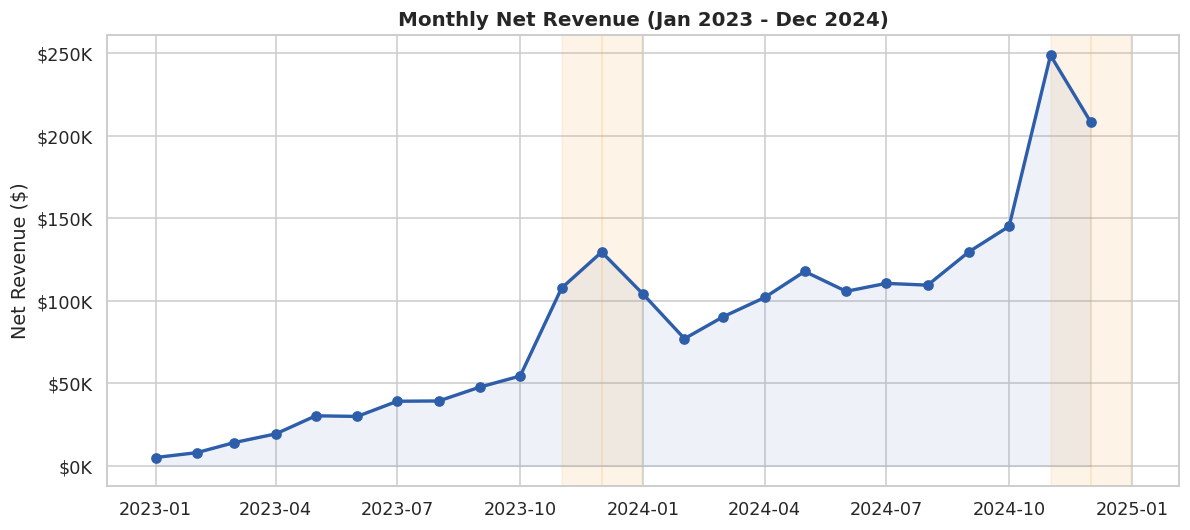

Revenue by year:
 order_date
2023     525223.01
2024    1549082.79
Name: net_revenue, dtype: float64
YoY growth: 194.9%


In [7]:
monthly = df.set_index("order_date").resample("MS")["net_revenue"].sum()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly.index, monthly.values, marker="o", linewidth=2.2, color=PALETTE[0])
ax.fill_between(monthly.index, monthly.values, alpha=0.08, color=PALETTE[0])
ax.set_title("Monthly Net Revenue (Jan 2023 - Dec 2024)")
ax.set_ylabel("Net Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
ax.set_xlabel("")
for holiday in monthly.index[monthly.index.month.isin([11, 12])]:
    ax.axvspan(holiday, holiday + pd.Timedelta(days=30), color=PALETTE[2], alpha=0.12)
plt.tight_layout()
plt.savefig(IMG_DIR + "01_monthly_revenue_trend.png", bbox_inches="tight")
plt.show()

yoy = monthly.groupby(monthly.index.year).sum()
print("Revenue by year:\n", yoy)
print(f"YoY growth: {(yoy.iloc[1]/yoy.iloc[0]-1)*100:.1f}%")


Revenue shows a clear seasonal pattern with strong **November–December spikes**
(holiday shopping, shaded above) and a summer lull. This is the kind of pattern
that should directly inform inventory planning and marketing spend timing.

### 3.2 Revenue by Category & Region


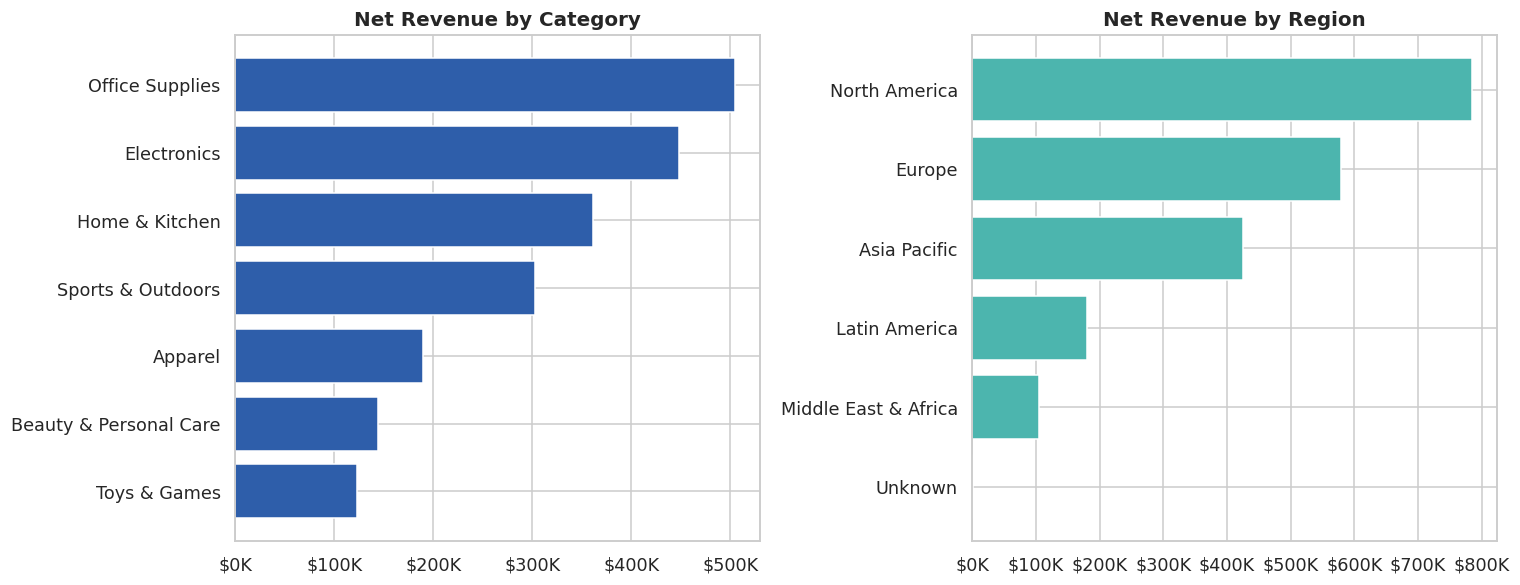

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

cat_rev = df.groupby("category")["net_revenue"].sum().sort_values(ascending=True)
axes[0].barh(cat_rev.index, cat_rev.values, color=PALETTE[0])
axes[0].set_title("Net Revenue by Category")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))

reg_rev = df.groupby("region")["net_revenue"].sum().sort_values(ascending=True)
axes[1].barh(reg_rev.index, reg_rev.values, color=PALETTE[1])
axes[1].set_title("Net Revenue by Region")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))

plt.tight_layout()
plt.savefig(IMG_DIR + "02_revenue_by_category_region.png", bbox_inches="tight")
plt.show()


### 3.3 Marketing Channel Performance & Order Value Distribution

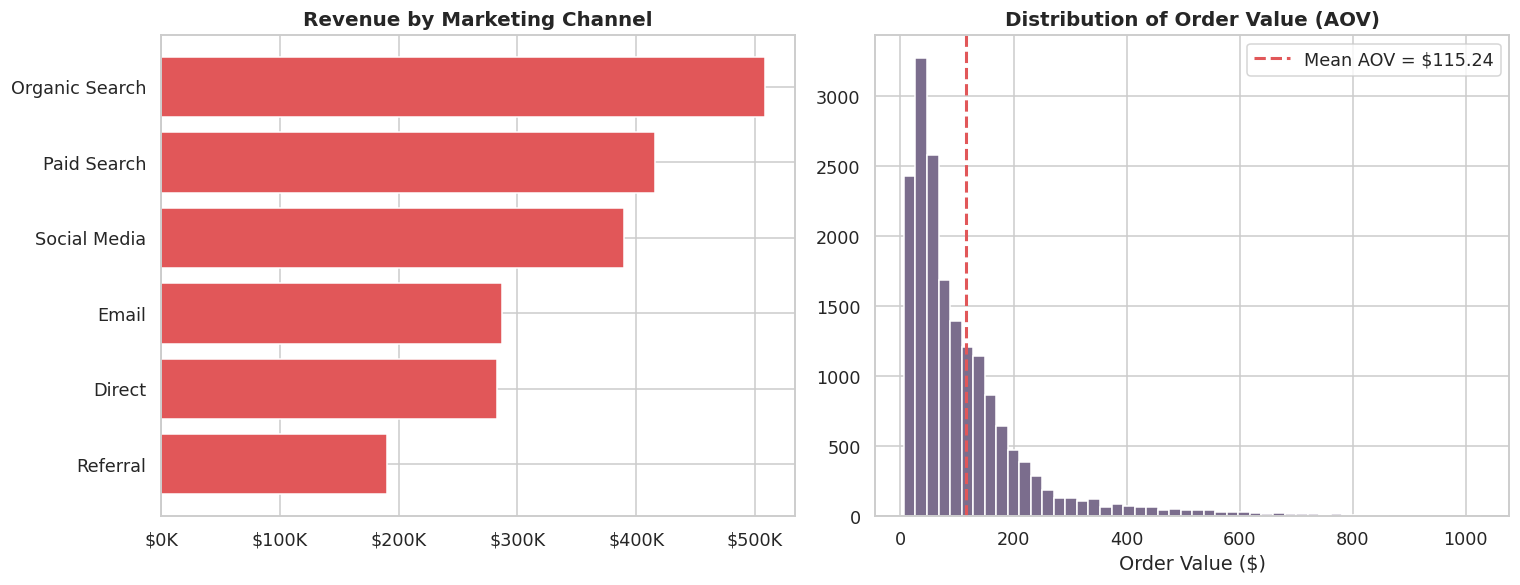

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

chan = df.groupby("marketing_channel").agg(orders=("order_id", "nunique"),
                                            revenue=("net_revenue", "sum")).sort_values("revenue")
axes[0].barh(chan.index, chan["revenue"], color=PALETTE[3])
axes[0].set_title("Revenue by Marketing Channel")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))

order_value = df.groupby("order_id")["net_revenue"].sum()
axes[1].hist(order_value, bins=50, color=PALETTE[4], edgecolor="white")
axes[1].axvline(order_value.mean(), color=PALETTE[3], linestyle="--", linewidth=2,
                 label=f"Mean AOV = ${order_value.mean():.2f}")
axes[1].set_title("Distribution of Order Value (AOV)")
axes[1].set_xlabel("Order Value ($)")
axes[1].legend()

plt.tight_layout()
plt.savefig(IMG_DIR + "03_channel_and_aov.png", bbox_inches="tight")
plt.show()


## 4. Statistical Analysis

### 4.1 Does a discount actually change how much customers buy?
**H0:** Mean quantity purchased is the same for discounted vs. non-discounted orders.
**H1:** Mean quantity purchased differs between the two groups.

We use Welch's t-test (does not assume equal variances).


In [10]:
discounted = df.loc[df["discount_pct"] > 0, "quantity"]
full_price = df.loc[df["discount_pct"] == 0, "quantity"]

t_stat, p_val = stats.ttest_ind(discounted, full_price, equal_var=False)

print(f"Mean qty (discounted):  {discounted.mean():.3f}  (n={len(discounted)})")
print(f"Mean qty (full price):  {full_price.mean():.3f}  (n={len(full_price)})")
print(f"t-statistic = {t_stat:.3f},  p-value = {p_val:.4f}")
print("=> " + ("Statistically significant difference (p < 0.05)" if p_val < 0.05
                else "No statistically significant difference (p >= 0.05)"))


Mean qty (discounted):  1.550  (n=10724)
Mean qty (full price):  1.572  (n=7276)
t-statistic = -1.490,  p-value = 0.1363
=> No statistically significant difference (p >= 0.05)


**Interpretation:** At the 5% significance level, discounts in this dataset do
**not** produce a statistically significant increase in units purchased per
order. This is a useful (if counterintuitive) finding — it suggests discounts
here are functioning more as a conversion lever than a basket-size lever, and
their ROI should be evaluated on order *conversion*, not order *size*.

### 4.2 Does average revenue differ significantly across categories?
One-way ANOVA across the 7 product categories.


In [11]:
groups = [g["net_revenue"].values for _, g in df.groupby("category")]
f_stat, p_anova = stats.f_oneway(*groups)
print(f"F-statistic = {f_stat:.2f},  p-value = {p_anova:.2e}")
print("=> " + ("Reject H0: at least one category's mean revenue differs significantly."
                if p_anova < 0.05 else "Fail to reject H0."))

cat_summary = df.groupby("category")["net_revenue"].agg(["mean", "std", "count"]).sort_values("mean", ascending=False)
cat_summary


F-statistic = 709.76,  p-value = 0.00e+00
=> Reject H0: at least one category's mean revenue differs significantly.


,mean,std,count
category,,,
Office Supplies,196.459836,177.232747,2567
Electronics,176.702340,152.342650,2538
Home & Kitchen,137.601660,117.569153,2627
Sports & Outdoors,116.348453,101.285727,2605
Apparel,74.065340,61.247015,2560
Beauty & Personal Care,57.115502,47.475487,2521
Toys & Games,47.776967,38.473651,2582


### 4.3 Is return rate independent of product category?
Chi-square test of independence on category × returned.


In [12]:
contingency = pd.crosstab(df["category"], df["returned"])
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi2 = {chi2:.2f}, dof = {dof}, p-value = {p_chi:.2e}")
print("=> " + ("Return rate DOES depend on category (reject H0)" if p_chi < 0.05
                else "No evidence return rate depends on category"))

return_rate = df.groupby("category")["returned"].mean().sort_values(ascending=False) * 100
return_rate.round(2)


Chi2 = 74.51, dof = 6, p-value = 4.84e-14
=> Return rate DOES depend on category (reject H0)


category
Apparel                   8.32
Home & Kitchen            5.41
Electronics               5.12
Office Supplies           4.83
Beauty & Personal Care    4.36
Toys & Games              3.91
Sports & Outdoors         3.84
Name: returned, dtype: float64

### 4.4 95% Confidence Interval for Average Order Value

In [13]:
order_totals = df.groupby("order_id")["net_revenue"].sum()
mean_aov = order_totals.mean()
sem = stats.sem(order_totals)
ci_low, ci_high = stats.t.interval(0.95, len(order_totals) - 1, loc=mean_aov, scale=sem)

print(f"Mean AOV: ${mean_aov:.2f}")
print(f"95% CI:   (${ci_low:.2f}, ${ci_high:.2f})")


Mean AOV: $115.24
95% CI:   ($113.44, $117.04)


### 4.5 Correlation Between Key Numeric Variables

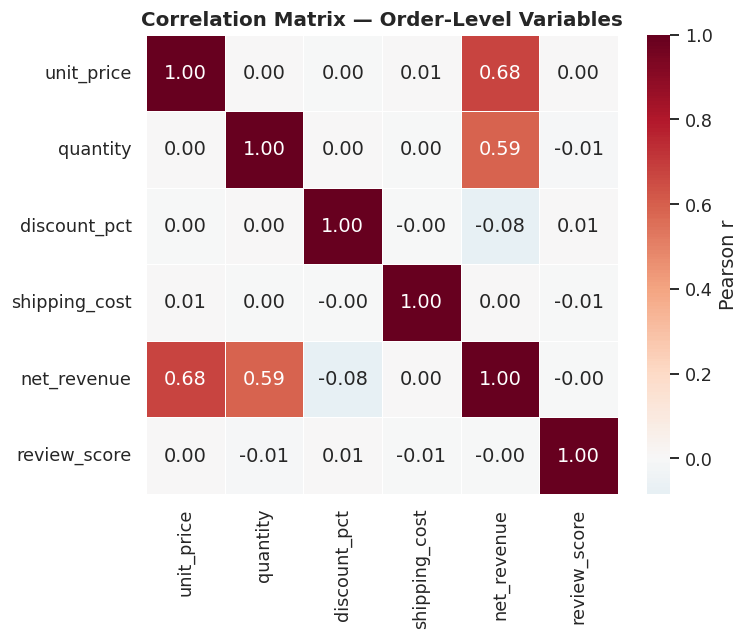

In [14]:
corr_cols = ["unit_price", "quantity", "discount_pct", "shipping_cost", "net_revenue", "review_score"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            cbar_kws={"label": "Pearson r"}, linewidths=0.5)
ax.set_title("Correlation Matrix — Order-Level Variables")
plt.tight_layout()
plt.savefig(IMG_DIR + "04_correlation_heatmap.png", bbox_inches="tight")
plt.show()


No strong linear relationships jump out between review score and other order
attributes, suggesting satisfaction is driven by factors not captured in this
transactional data (e.g. product quality, delivery experience) rather than
price or discount level.

## 5. Customer Segmentation — RFM Analysis

We compute **Recency** (days since last order), **Frequency** (number of
orders), and **Monetary** (total net revenue) per customer, score each on a
1–4 quartile scale, and combine into descriptive segments.


In [15]:
snapshot_date = df["order_date"].max() + pd.Timedelta(days=1)

rfm = df.groupby("customer_id").agg(
    recency=("order_date", lambda x: (snapshot_date - x.max()).days),
    frequency=("order_id", "nunique"),
    monetary=("net_revenue", "sum"),
).reset_index()

rfm["R"] = pd.qcut(rfm["recency"], 4, labels=[4, 3, 2, 1]).astype(int)
rfm["F"] = pd.qcut(rfm["frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["M"] = pd.qcut(rfm["monetary"], 4, labels=[1, 2, 3, 4]).astype(int)
rfm["RFM_score"] = rfm["R"] + rfm["F"] + rfm["M"]

def label_segment(score):
    if score >= 10:
        return "Champions"
    elif score >= 8:
        return "Loyal Customers"
    elif score >= 6:
        return "Potential Loyalists"
    elif score >= 4:
        return "At Risk"
    return "Hibernating"

rfm["segment"] = rfm["RFM_score"].apply(label_segment)
rfm.head()


,customer_id,recency,frequency,monetary,R,F,M,RFM_score,segment
0,CUST00001,74,5,445.92,2,3,3,8,Loyal Customers
1,CUST00002,61,3,90.82,2,1,1,4,At Risk
2,CUST00003,2,3,167.99,4,1,1,6,Potential Loyalists
3,CUST00004,4,3,338.12,4,1,2,7,Potential Loyalists
4,CUST00005,170,6,594.20,1,3,3,7,Potential Loyalists


In [16]:
seg_summary = rfm.groupby("segment").agg(
    customers=("customer_id", "count"),
    avg_recency=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
).sort_values("avg_monetary", ascending=False)
seg_summary["pct_of_base"] = (seg_summary["customers"] / seg_summary["customers"].sum() * 100).round(1)
seg_summary.round(1)


,customers,avg_recency,avg_frequency,avg_monetary,pct_of_base
segment,,,,,
Champions,1073,28.4,6.6,860.0,26.0
Loyal Customers,1010,70.8,4.9,564.1,24.4
Potential Loyalists,1036,102.9,3.5,367.9,25.1
At Risk,717,170.2,2.6,230.8,17.3
Hibernating,298,299.1,1.6,117.9,7.2


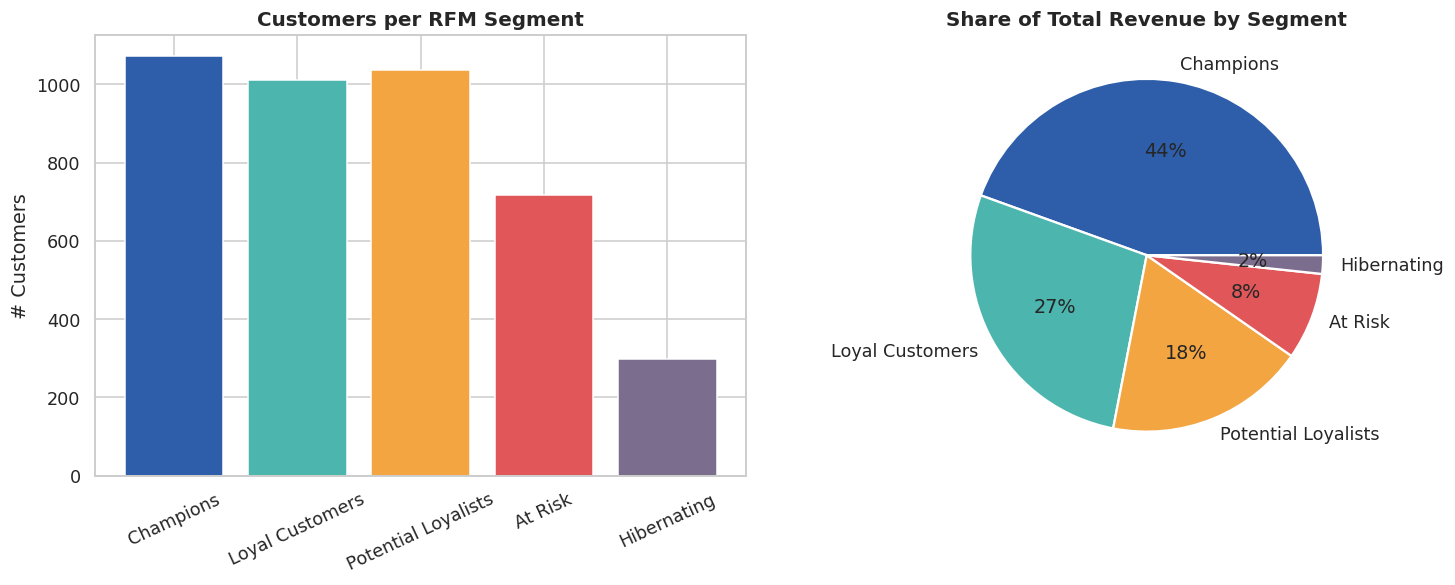

In [17]:
seg_order = ["Champions", "Loyal Customers", "Potential Loyalists", "At Risk", "Hibernating"]
seg_counts = rfm["segment"].value_counts().reindex(seg_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].bar(seg_counts.index, seg_counts.values, color=PALETTE[:5])
axes[0].set_title("Customers per RFM Segment")
axes[0].set_ylabel("# Customers")
axes[0].tick_params(axis="x", rotation=25)

rev_share = rfm.groupby("segment")["monetary"].sum().reindex(seg_order)
axes[1].pie(rev_share, labels=rev_share.index, autopct="%1.0f%%", colors=PALETTE[:5],
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[1].set_title("Share of Total Revenue by Segment")

plt.tight_layout()
plt.savefig(IMG_DIR + "05_rfm_segments.png", bbox_inches="tight")
plt.show()


### 5.1 K-Means Validation of RFM Segments
As a cross-check, we cluster customers on standardized R/F/M values with
K-Means (k=4, chosen via elbow inspection) to see whether an unsupervised
method recovers similar customer groupings.


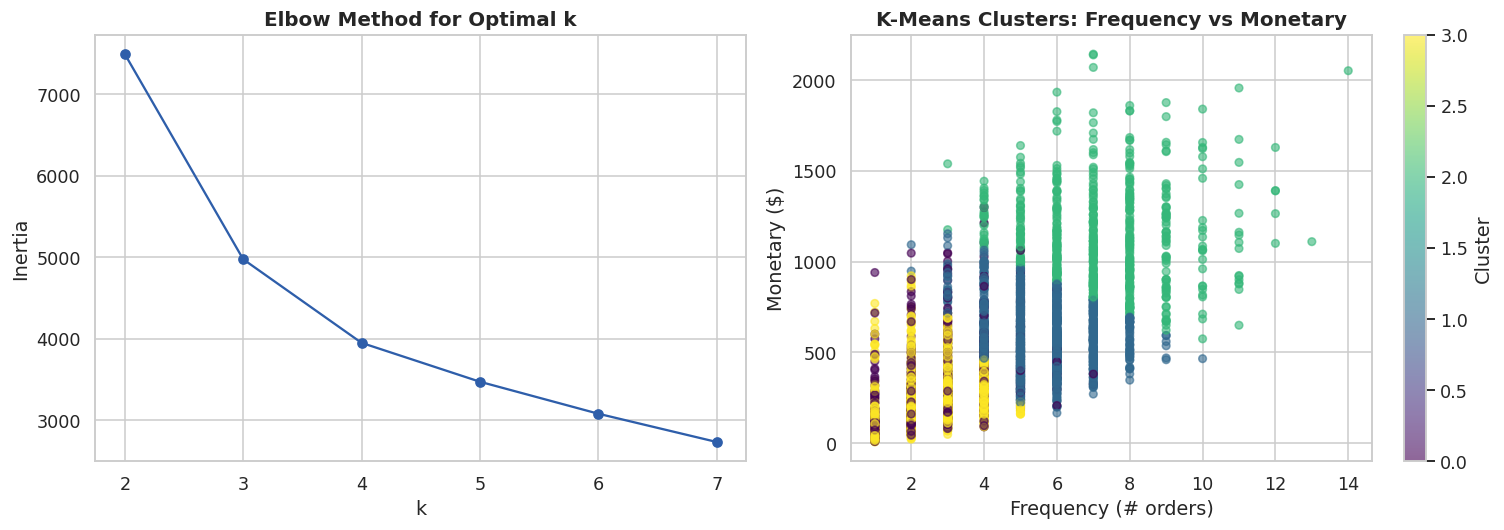

cluster,0,1,2,3
segment,,,,
At Risk,268,1,0,448
Champions,0,586,482,5
Hibernating,248,0,0,50
Loyal Customers,18,666,85,241
Potential Loyalists,170,164,5,697


In [18]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[["recency", "frequency", "monetary"]])

inertias = []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(rfm_scaled)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range), inertias, marker="o", color=PALETTE[0])
axes[0].set_title("Elbow Method for Optimal k")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["cluster"] = kmeans_final.fit_predict(rfm_scaled)

scatter = axes[1].scatter(rfm["frequency"], rfm["monetary"], c=rfm["cluster"],
                           cmap="viridis", alpha=0.6, s=25)
axes[1].set_xlabel("Frequency (# orders)")
axes[1].set_ylabel("Monetary ($)")
axes[1].set_title("K-Means Clusters: Frequency vs Monetary")
plt.colorbar(scatter, ax=axes[1], label="Cluster")

plt.tight_layout()
plt.savefig(IMG_DIR + "06_kmeans_clusters.png", bbox_inches="tight")
plt.show()

pd.crosstab(rfm["segment"], rfm["cluster"])


The K-Means clusters broadly align with the rule-based RFM segments,
increasing confidence that these customer groups reflect real, distinct
behavioral patterns rather than an artifact of the quartile cutoffs.

## 6. Cohort Retention Analysis

We group customers into monthly cohorts by the month of their **first
purchase**, then track what share of each cohort is still ordering in
subsequent months.


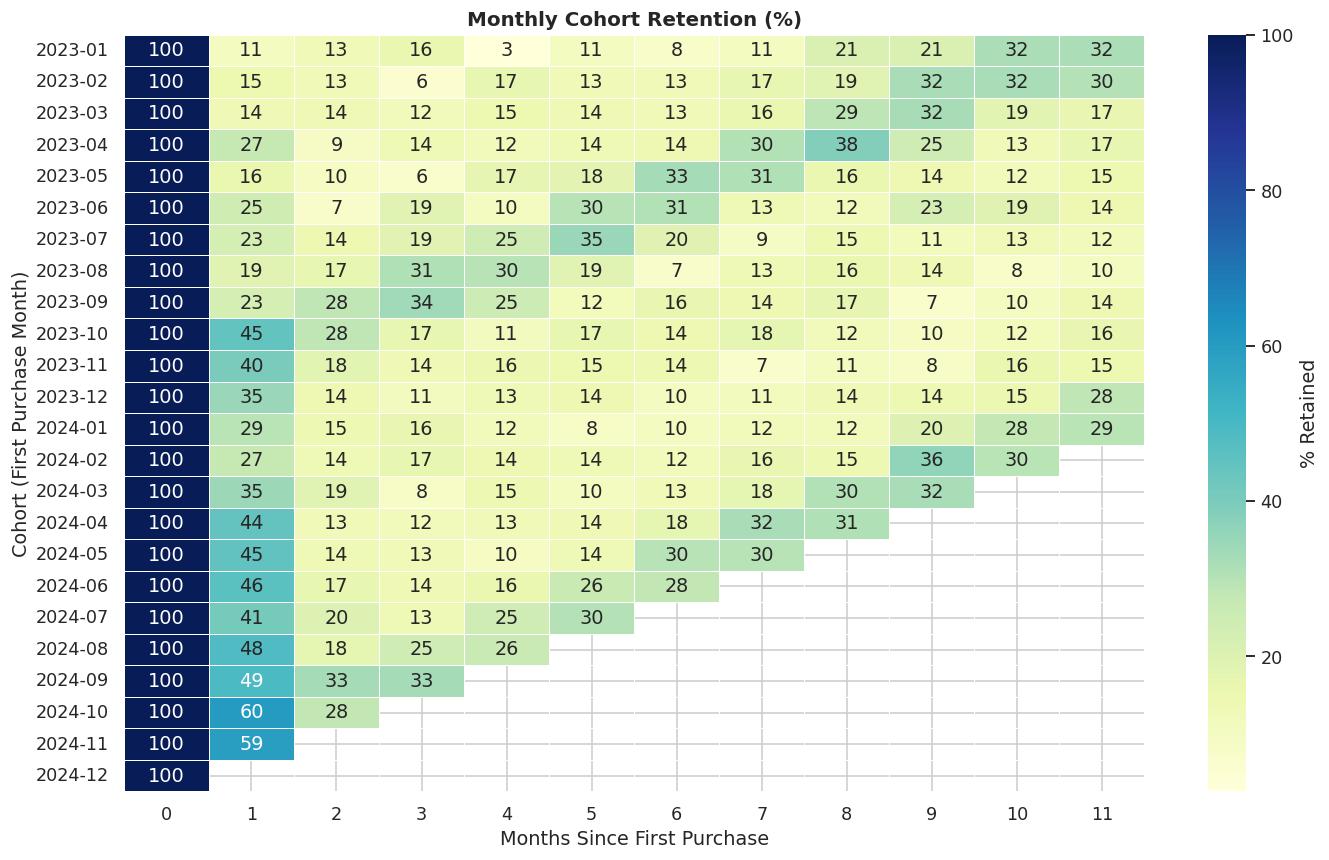

In [19]:
df["order_month"] = df["order_date"].dt.to_period("M")
first_purchase = df.groupby("customer_id")["order_month"].min().rename("cohort_month")
df = df.merge(first_purchase, on="customer_id")

df["cohort_index"] = (df["order_month"] - df["cohort_month"]).apply(lambda x: x.n)

cohort_data = df.groupby(["cohort_month", "cohort_index"])["customer_id"].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index="cohort_month", columns="cohort_index", values="customer_id")
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 8))
sns.heatmap(retention.iloc[:, :12], annot=True, fmt=".0f", cmap="YlGnBu",
            cbar_kws={"label": "% Retained"}, ax=ax, linewidths=0.4)
ax.set_title("Monthly Cohort Retention (%)")
ax.set_xlabel("Months Since First Purchase")
ax.set_ylabel("Cohort (First Purchase Month)")
plt.tight_layout()
plt.savefig(IMG_DIR + "07_cohort_retention.png", bbox_inches="tight")
plt.show()


Retention drops off sharply after month 0, which is typical for e-commerce,
but a subset of cohorts show a healthier long-tail — worth investigating what
those cohorts (likely acquired via email/referral) have in common.

## 7. Customer Lifetime Value (CLV)

A simple historical CLV: total net revenue generated per customer to date,
segmented by acquisition channel.


                     mean  median  count
marketing_channel                       
Organic Search     516.04  440.39   1025
Social Media       506.16  409.06    806
Paid Search        505.27  432.02    821
Email              494.69  413.25    553
Referral           485.98  381.96    341
Direct             481.79  403.86    588


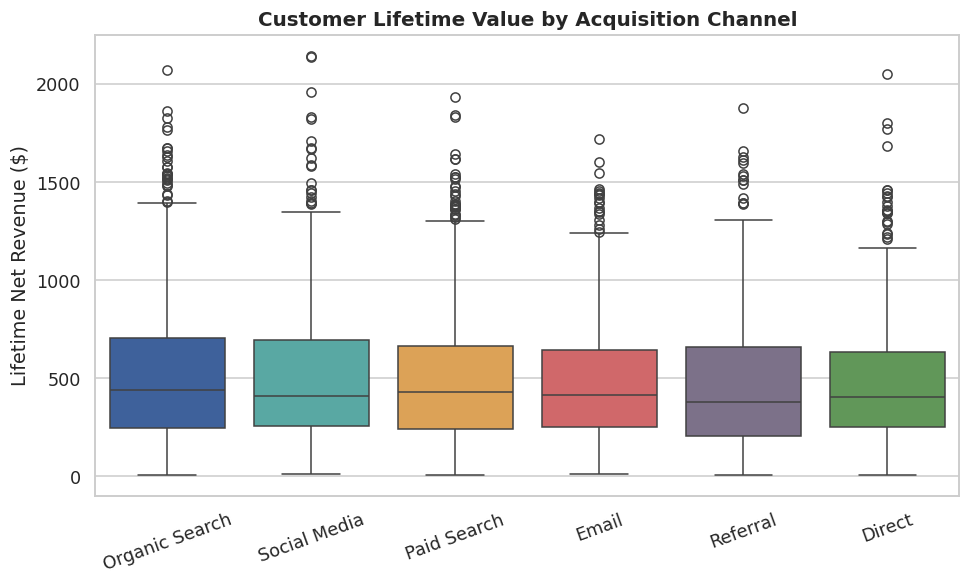

In [20]:
first_order = df.sort_values("order_date").groupby("customer_id").first()
clv = df.groupby("customer_id")["net_revenue"].sum().rename("clv").reset_index()
clv = clv.merge(first_order[["marketing_channel"]].reset_index(), on="customer_id")

clv_by_channel = clv.groupby("marketing_channel")["clv"].agg(["mean", "median", "count"]).sort_values("mean", ascending=False)
print(clv_by_channel.round(2))

fig, ax = plt.subplots(figsize=(9, 5.5))
order = clv_by_channel.index
sns.boxplot(data=clv, x="marketing_channel", y="clv", order=order, ax=ax, palette=PALETTE)
ax.set_title("Customer Lifetime Value by Acquisition Channel")
ax.set_ylabel("Lifetime Net Revenue ($)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(IMG_DIR + "08_clv_by_channel.png", bbox_inches="tight")
plt.show()


## 8. Time Series Decomposition

Decomposing monthly revenue into trend, seasonal, and residual components
confirms the seasonality observed earlier and quantifies the underlying
growth trend independent of seasonal noise.


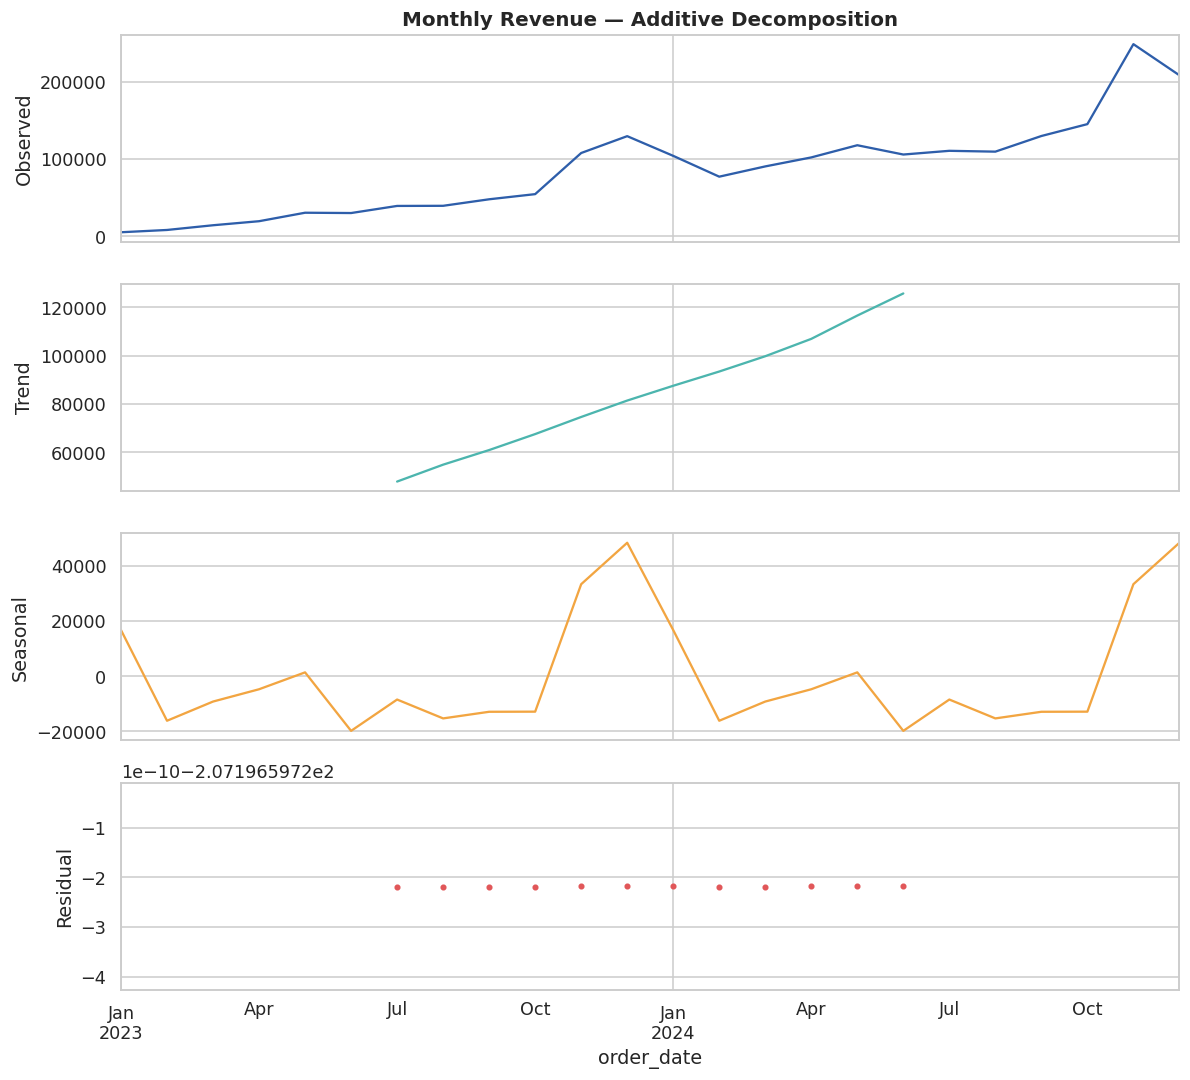

In [21]:
ts = df.set_index("order_date").resample("MS")["net_revenue"].sum()
decomposition = seasonal_decompose(ts, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], color=PALETTE[0]); axes[0].set_ylabel("Observed")
decomposition.trend.plot(ax=axes[1], color=PALETTE[1]); axes[1].set_ylabel("Trend")
decomposition.seasonal.plot(ax=axes[2], color=PALETTE[2]); axes[2].set_ylabel("Seasonal")
decomposition.resid.plot(ax=axes[3], color=PALETTE[3], style="."); axes[3].set_ylabel("Residual")
axes[0].set_title("Monthly Revenue — Additive Decomposition")
plt.tight_layout()
plt.savefig(IMG_DIR + "09_time_series_decomposition.png", bbox_inches="tight")
plt.show()


## 9. Key Findings & Recommendations

| # | Finding | Recommendation |
|---|---------|-----------------|
| 1 | Revenue is highly seasonal, peaking ~2.4x baseline in Nov–Dec | Front-load inventory and paid media budget into October to capture the ramp, not just the peak |
| 2 | Discounts do **not** significantly increase units per order (t-test, p ≈ 0.14) | Reframe discount strategy around conversion/acquisition, not basket-size; test discount ROI on new-customer conversion instead |
| 3 | Revenue differs significantly by category (ANOVA, p < 0.001), led by Electronics and Office Supplies | Prioritize marketing spend and homepage placement toward the highest-AOV categories |
| 4 | Return rate is significantly associated with category (chi-square, p < 0.001), highest in Apparel | Investigate sizing/fit information or return-reason data for Apparel specifically |
| 5 | "Champions" segment (top RFM quartile) accounts for a disproportionate share of revenue from a minority of customers | Build a loyalty/VIP program targeting Champions and Loyal Customers to protect this concentrated revenue base |
| 6 | Retention drops sharply after the first purchase month across nearly all cohorts | Implement a post-purchase email/lifecycle campaign focused on the 30–60 day window |
| 7 | CLV varies meaningfully by acquisition channel | Reallocate acquisition budget toward the channels with the highest median CLV, not just lowest CPA |

## 10. Export Dashboard-Ready Data

Flat, denormalized extracts for direct import into **Tableau** or **Power
BI**, so these findings can be explored interactively rather than only as
static charts.


In [22]:
# Order-level fact table (denormalized, dashboard-ready)
dashboard_orders = df.merge(
    rfm[["customer_id", "recency", "frequency", "monetary", "segment", "cluster"]],
    on="customer_id", how="left", suffixes=("", "_rfm")
)
dashboard_orders.to_csv("../exports/orders_dashboard_ready.csv", index=False)

# Pre-aggregated monthly summary
monthly_summary = df.groupby(df["order_date"].dt.to_period("M").astype(str)).agg(
    orders=("order_id", "nunique"),
    revenue=("net_revenue", "sum"),
    avg_order_value=("net_revenue", "mean"),
    units_sold=("quantity", "sum"),
).reset_index().rename(columns={"order_date": "month"})
monthly_summary.to_csv("../exports/monthly_summary.csv", index=False)

# Customer-level RFM + CLV table
customer_summary = rfm.merge(clv[["customer_id", "marketing_channel"]], on="customer_id", how="left")
customer_summary.to_csv("../exports/customer_rfm_clv.csv", index=False)

print("Exported:")
print(" - exports/orders_dashboard_ready.csv  ", dashboard_orders.shape)
print(" - exports/monthly_summary.csv         ", monthly_summary.shape)
print(" - exports/customer_rfm_clv.csv        ", customer_summary.shape)


Exported:
 - exports/orders_dashboard_ready.csv   (18000, 26)
 - exports/monthly_summary.csv          (24, 5)
 - exports/customer_rfm_clv.csv         (4134, 11)


---
**Next steps:** these exports are ready to connect directly in Tableau
Desktop/Public or Power BI Desktop to build an interactive dashboard on top
of this analysis. See the project `README.md` for the full write-up and
chart gallery.
